**Setup and Imports**

In [2]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple
from sentence_transformers import SentenceTransformer, util
from PIL import Image
from abc import ABC, abstractmethod
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
print(torch.__version__)

2.6.0


**Abstract SubModularFunction**

In [3]:
class SubModularFunction(ABC):
    @abstractmethod
    def evaluate(self, selected_indices: List[int]) -> float:
        pass

    @abstractmethod
    def marginal_gain(self, selected_indices: List[int], candidate_index: int) -> float:
        pass

In [4]:
class LabelSampleCosine(SubModularFunction):
    def __init__(self, X_pool: np.ndarray):
        super().__init__()

        self.similarity_matrix = cosine_similarity(X_pool)
        self.similarity_matrix = np.clip(self.similarity_matrix, 0.0, 1.0)
    
    def evaluate(self, selected_indices: List[int]) -> float:
        if not selected_indices:
            return 0.0
        sub_matrix = self.similarity_matrix[:, selected_indices]
        max_similarities = np.max(sub_matrix, axis=1)
        return np.sum(max_similarities)
    
    def marginal_gain(self, selected_indices, candidate_index):
        current_score = self.evaluate(selected_indices)
        new_indices = selected_indices + [candidate_index]
        new_score = self.evaluate(new_indices)
        return new_score - current_score


**Optimiser**

In [5]:
class GPUFacilityLocationOptimizer:
    """
    A vectorized GPU implementation of the Facility Location greedy optimizer.

    This class computes the cosine similarity matrix directly on the GPU and 
    uses tensor broadcasting to evaluate all candidates simultaneously. This 
    eliminates the need for nested Python loops and drastically accelerates 
    the selection process for large datasets.
    """

    def __init__(self, embeddings: torch.Tensor):
        """
        Initializes the optimizer by computing the similarity matrix on the GPU.

        Args:
            embeddings: A PyTorch tensor of feature vectors. It should already 
                        be loaded onto the target device.
        """
        self.device = embeddings.device
        self.num_samples = embeddings.shape[0]

        normalized_embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
        self.similarity_matrix = torch.mm(normalized_embeddings, normalized_embeddings.t())
        self.similarity_matrix = torch.clamp(self.similarity_matrix, min=0.0, max=1.0)

    def select(self, budget: int) -> List[int]:
        """
        Selects a subset of indices using a vectorized greedy strategy.

        Args:
            budget: The maximum number of items to select from the pool.

        Returns:
            A list of integers representing the indices of the selected items.
        """
        selected_indices = []
        
        current_max_similarities = torch.zeros(self.num_samples, device=self.device)

        for _ in range(budget):
            broadcasted_max = current_max_similarities.unsqueeze(1)
            potential_new_maxes = torch.maximum(broadcasted_max, self.similarity_matrix)
            
            candidate_scores = torch.sum(potential_new_maxes, dim=0)
            
            if selected_indices:
                candidate_scores[selected_indices] = float('-inf')
            
            best_candidate_tensor = torch.argmax(candidate_scores)
            best_candidate = best_candidate_tensor.item()
            
            selected_indices.append(best_candidate)
            current_max_similarities = potential_new_maxes[:, best_candidate]

        return selected_indices

**Extract Embeddings**

In [6]:
extensions = ["jpg", "png", "jpeg"]
image_paths = []

for ext in extensions:
    image_paths.extend(
        glob.glob(f"PetImages/**/*.{ext}", recursive=True)
    )

batch_size = 32
model = SentenceTransformer("sentence-transformers/clip-ViT-B-32")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
model.to(device)
model.eval()

all_embeddings = []

with torch.no_grad():
    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i + batch_size]
        images = [Image.open(path).convert('RGB') for path in batch_paths]

        embeddings = model.encode(images)
        all_embeddings.append(embeddings)

all_pro_embeddings = np.vstack(all_embeddings)


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


cuda


In [7]:
print(all_pro_embeddings.shape)

(16346, 512)


**Label and Test**

Calculating the most representative images on GPU. Please wait.
Beginning interactive labeling session.


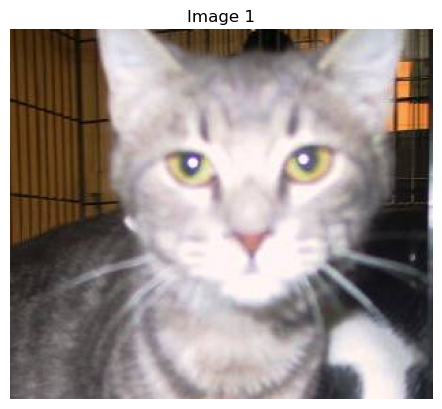

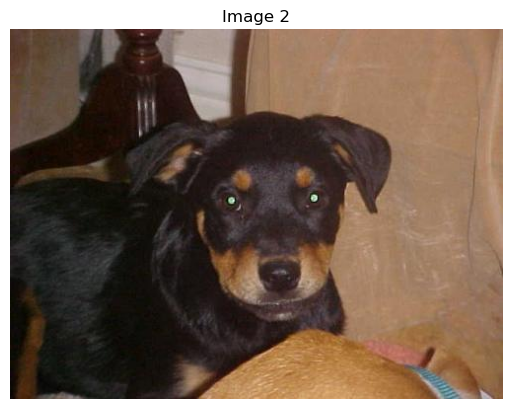

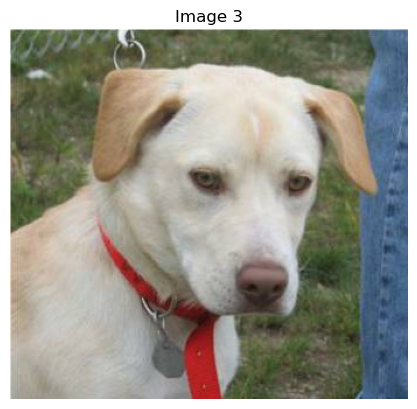

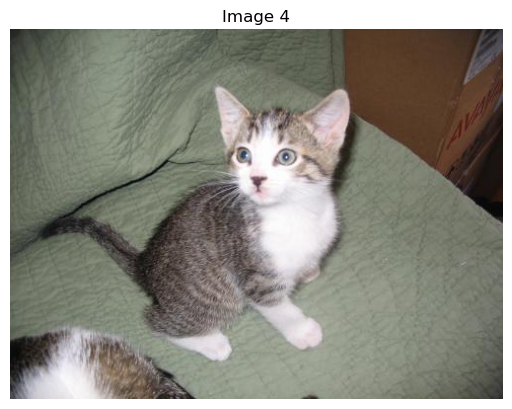

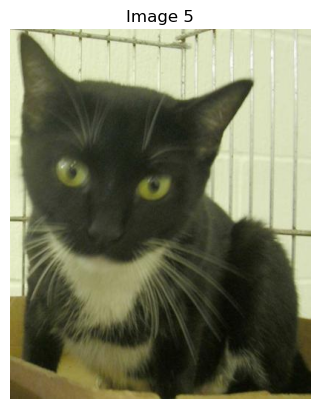

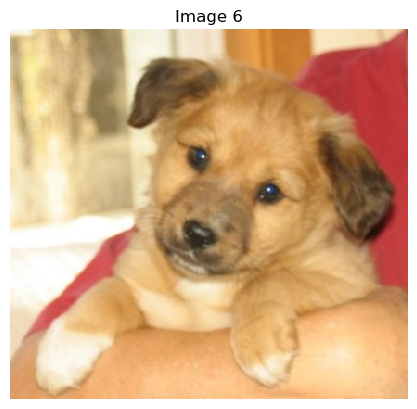

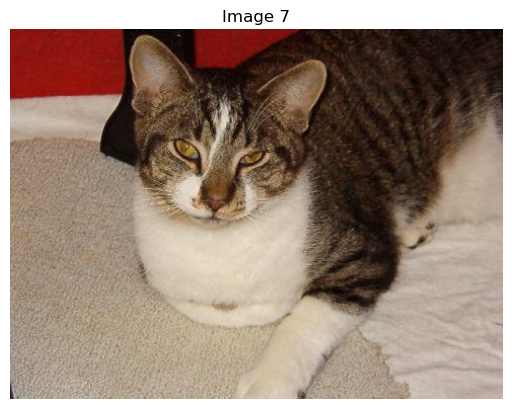

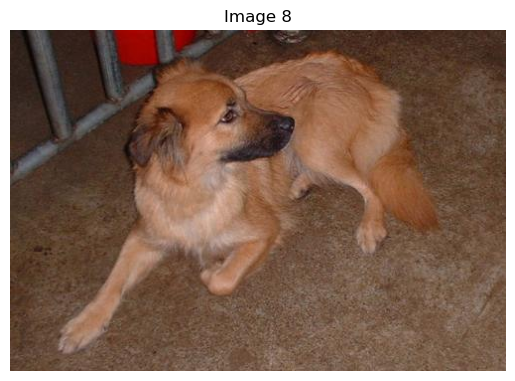

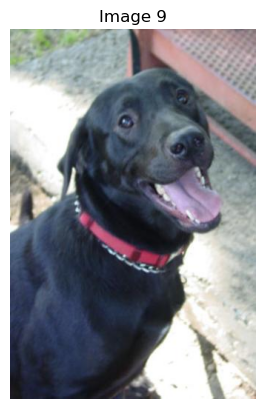

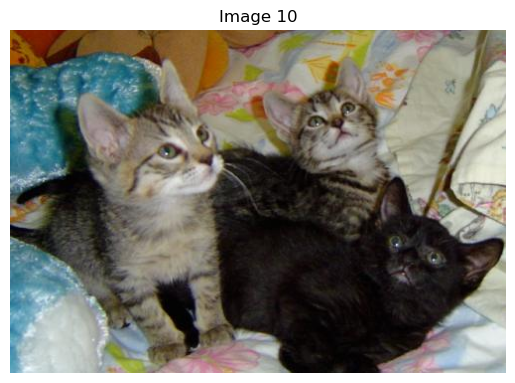

Training the classifier.


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [9]:
objective = LabelSampleCosine(all_pro_embeddings)
embeddings_tensor = torch.tensor(all_pro_embeddings, dtype=torch.float32, device=device)
gpu_optimizer = GPUFacilityLocationOptimizer(embeddings_tensor)

print("Calculating the most representative images on GPU. Please wait.")
selected_indices = gpu_optimizer.select(budget=10)

user_labels = []

print("Beginning interactive labeling session.")

for i, index in enumerate(selected_indices):
        current_path = image_paths[index]
        
        img = Image.open(current_path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Image {i + 1}")
        plt.show(block=False)
        plt.pause(0.1)

        while True:
            user_input = input("Enter label type cat or dog: ").strip().lower()
            if user_input in ['cat', 'dog']:
                label = 0 if user_input == 'cat' else 1
                user_labels.append(label)
                break
            else:
                print("Invalid input. Type cat or dog.")
        
        plt.close()

print("Training the classifier.")

training_features = all_pro_embeddings[selected_indices]
training_labels =  np.array(user_labels)

classifier = LogisticRegression(max_iter=1000)
classifier.fit(training_features, training_labels)


In [11]:
true_labels = []

for path in image_paths:
    if 'dog' in path.lower():
            true_labels.append(1)
    elif 'cat' in path.lower():
            true_labels.append(0)
    else:
            raise ValueError("Path must contain either cat or dog directory names.")

true_labels = np.array(true_labels)

predictions = classifier.predict(all_pro_embeddings)
accuracy = accuracy_score(true_labels, predictions)

print(f"Final Model Accuracy on all {len(all_pro_embeddings)} images: {accuracy * 100:.2f} percent")

Final Model Accuracy on all 16346 images: 99.56 percent
